# Test Random Bootstrap Compatibility

Verify that the updated odds_ratio_test script produces identical results when using randomized null distributions (run_permulations=False) compared to the original implementation.

This notebook uses the same test cases as the original but with updated parameter names:
- `alternative="less"` → `alternative="LT"`
- `alternative="greater"` → `alternative="RT"`
- `run_permulations=False` to use original randomized bootstrap

## Setup

In [53]:
import os
import sys

# Make src importable whether cwd is repo root or scripts/
cwd = os.getcwd()
if os.path.basename(cwd) == "scripts":
    repo_root = os.path.abspath(os.path.join(cwd, ".."))
else:
    repo_root = cwd

src_path = os.path.join(repo_root, "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

print(f"Using src path: {src_path}")

# Import the module from src/
import odds_ratio_test as ort

Using src path: /Users/calvin/orb-selection/src


In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Test old version: Loss, Left-Tailed (occupancy 50-95)

`run_permulations=False`

98 species total, 44 foreground, 54 background

LAUNCHING PERMUTATION TEST

** Maximum occupancy set to 95 **

** Minimum occupancy set to 50 **

Counting permuted distributions in which statistics
derived from randomly assigned test groups are SMALLER
than the true distribution's statistics (left-tailed)...



100%|██████████| 10000/10000 [05:13<00:00, 31.86it/s]



Permutation counter for MEAN: 0
Permutation counter for STD DEV: 10000
Permutation counter for SKEW: 8113

Filtering log odds ratio results df for occupancy >= 50, <= 95
and log odds ratio threshold [-1.3627994   1.37019336]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Permutation test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *50* and maximum occupancy *95* 
Analysis run on 2026-03-19 at 17:24:50
Foreground list: /Users/calvin/orb-selection/assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6503994164568763
True standard deviation: 1.5251594203369667
True skew: 0.20218325296976208

** PERMUTATION P-VALUES ** 

Probability 

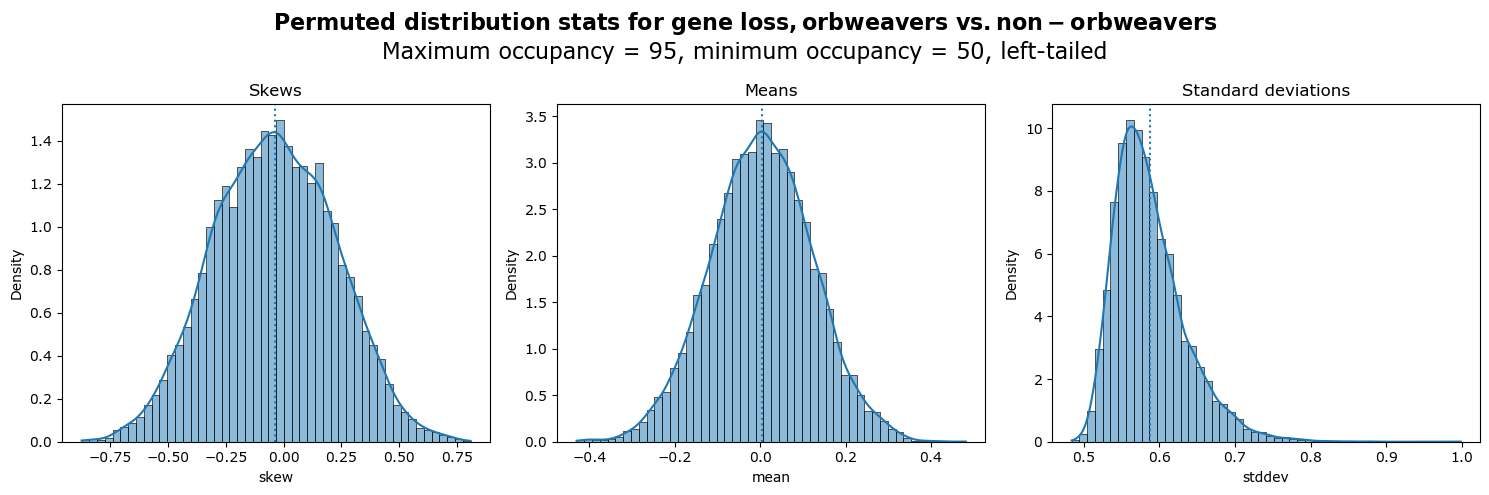

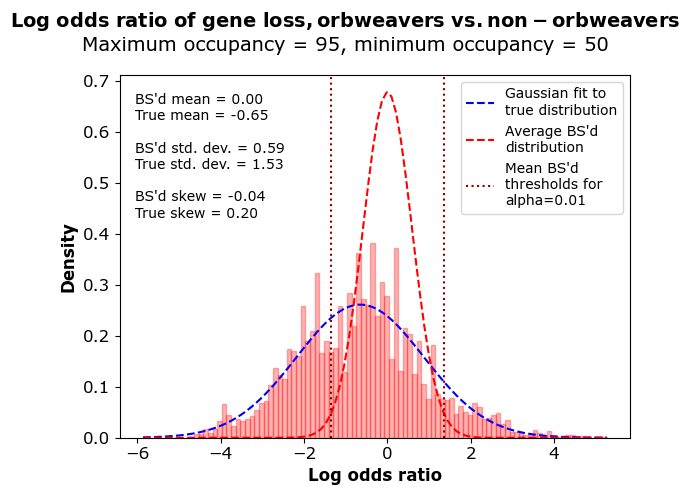

In [22]:
loss_lt_50_95 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=50,
    max_occ=95,
    alpha=0.01,
    alternative="LT",
    run_permulations=False,  # Use original randomized bootstrap
    species_of_interest="Uloborus_diversus",
    results_dir=f"~/kelvin-scratch/random_bootstrap_test/",
    fg_name='orbweavers',
    bg_name='non-orbweavers'
)

## Test new version: Loss, Left-Tailed (occupancy 50-95)

`run_permulations=True`

In [54]:
%reload_ext autoreload

98 species total, 44 foreground, 54 background
First permulated tip values (species -> value):
{'Tekellina_sadamotoi': 0.0, 'Robertus_nojimai': 0.0, 'Latrodectus_hasseltii': 0.0, 'Steatoda_grossa': 0.0, 'Rhomphaea_labiata': 0.0, 'Argyrodes_flavescens': 0.0, 'Argyrodes_miniaceus': 0.0, 'Cryptachaea_gigantipes': 0.0, 'Parasteatoda_culicivora': 0.0, 'Chrysso_octomaculata': 0.0, 'Theridion_varians': 0.0, 'Metleucauge_yunohamensis': 0.0, 'Mesida_sp_IDV5268': 0.0, 'Leucauge_dromedari': 0.0, 'Tetragnatha_yesoensis': 1.0, 'Tetragnatha_vermiformis': 1.0, 'Tetragnatha_mandibulata': 1.0, 'Tetragnatha_maxillosa': 1.0, 'Tetragnatha_extensa': 0.0, 'Tetragnatha_filiciphilia': 1.0, 'Tetragnatha_paludicola': 1.0, 'Tetragnatha_stelarobusta': 1.0, 'Tetragnatha_quasimodo': 1.0, 'Tetragnatha_waikamoi': 1.0, 'Tetragnatha_brevignatha': 1.0, 'Phonognatha_graeffei': 0.0, 'Caerostris_darwini': 1.0, 'Caerostris_extrusa': 1.0, 'Araneus_inustus': 1.0, 'Cyrtophora_cicatrosa': 1.0, 'Argiope_bruennichi': 1.0, 'Argiop

100%|████████████████████████████████████| 10000/10000 [04:58<00:00, 33.53it/s]



Permutation counter for MEAN: 2160
Permutation counter for STD DEV: 8107
Permutation counter for SKEW: 6430

Filtering log odds ratio results df for occupancy >= 75, <= 95
and log odds ratio threshold [-3.20201399  3.12836134]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Permutation test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *75* and maximum occupancy *95* 
Analysis run on 2026-03-22 at 16:13:02
Foreground list: /Users/calvin/orb-selection/assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 2627
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6142556700338094
True standard deviation: 1.5114390673584646
True skew: 0.15829356773850894

** PERMUTATION P-VALUES ** 

Probabilit

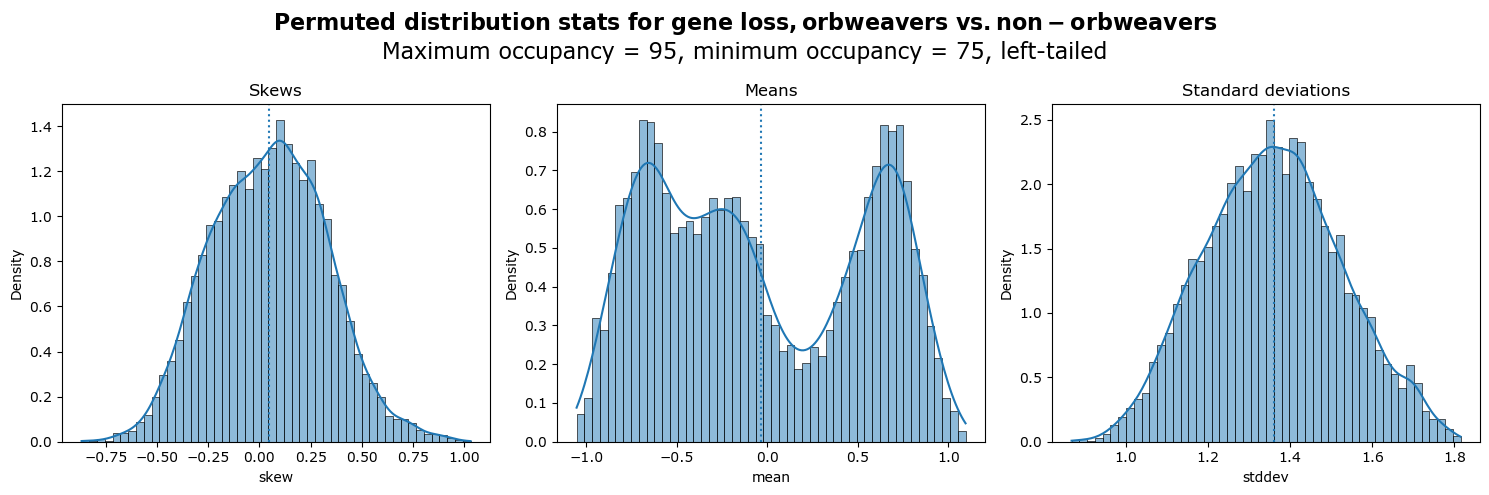

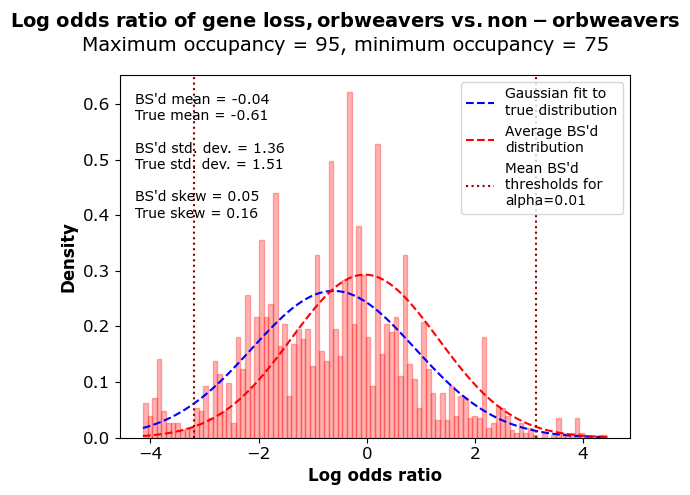

In [ ]:
loss_lt_75_95 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=75,
    max_occ=95,
    alpha=0.01,
    alternative="LT",
    species_of_interest="Uloborus_diversus",
    results_dir=f"~/kelvin-scratch/random_bootstrap_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
)

## Test new version: Duplication, Right-Tailed (occupancy 50-95)

`run_permulations=True`

98 species total, 44 foreground, 54 background
First permulated tip values (species -> value):
{'Tekellina_sadamotoi': 0.0, 'Robertus_nojimai': 0.0, 'Latrodectus_hasseltii': 0.0, 'Steatoda_grossa': 0.0, 'Rhomphaea_labiata': 0.0, 'Argyrodes_flavescens': 0.0, 'Argyrodes_miniaceus': 0.0, 'Cryptachaea_gigantipes': 0.0, 'Parasteatoda_culicivora': 0.0, 'Chrysso_octomaculata': 0.0, 'Theridion_varians': 0.0, 'Metleucauge_yunohamensis': 0.0, 'Mesida_sp_IDV5268': 0.0, 'Leucauge_dromedari': 0.0, 'Tetragnatha_yesoensis': 1.0, 'Tetragnatha_vermiformis': 1.0, 'Tetragnatha_mandibulata': 1.0, 'Tetragnatha_maxillosa': 1.0, 'Tetragnatha_extensa': 0.0, 'Tetragnatha_filiciphilia': 1.0, 'Tetragnatha_paludicola': 1.0, 'Tetragnatha_stelarobusta': 1.0, 'Tetragnatha_quasimodo': 1.0, 'Tetragnatha_waikamoi': 1.0, 'Tetragnatha_brevignatha': 1.0, 'Phonognatha_graeffei': 0.0, 'Caerostris_darwini': 1.0, 'Caerostris_extrusa': 1.0, 'Araneus_inustus': 1.0, 'Cyrtophora_cicatrosa': 1.0, 'Argiope_bruennichi': 1.0, 'Argiop

100%|████████████████████████████████████| 10000/10000 [05:04<00:00, 32.87it/s]



Permutation counter for MEAN: 3254
Permutation counter for STD DEV: 3224
Permutation counter for SKEW: 2592

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-2.15794692  2.15126142]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Permutation test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2026-03-21 at 12:30:03
Foreground list: /Users/calvin/orb-selection/assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: 0.03160642446865215
True standard deviation: 0.9571114734826476
True skew: 0.11458150220697833

** PERMUTATION P-VALUES ** 

Pr

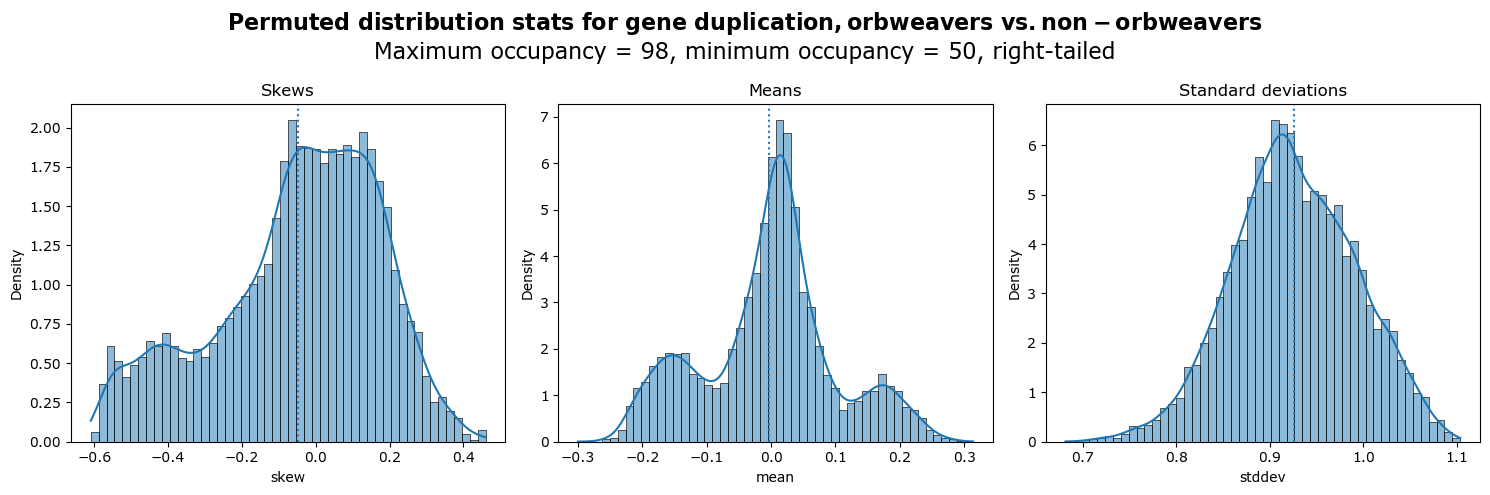

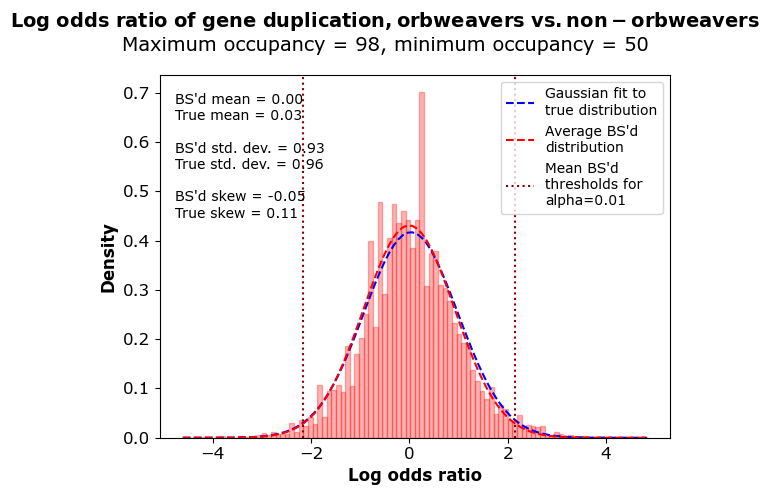

In [48]:
dup_rt_50_98 = ort.odds_ratio_test(
    test="duplication",
    occupancy_threshold=50,
    max_occ=98,
    alpha=0.01,
    alternative="RT",
    species_of_interest="Uloborus_diversus",
    results_dir=f"~/kelvin-scratch/random_bootstrap_test/",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
)

98 species total, 44 foreground, 54 background
First permulated tip values (species -> value):
{'Tekellina_sadamotoi': 0.0, 'Robertus_nojimai': 0.0, 'Latrodectus_hasseltii': 0.0, 'Steatoda_grossa': 0.0, 'Rhomphaea_labiata': 0.0, 'Argyrodes_flavescens': 0.0, 'Argyrodes_miniaceus': 0.0, 'Cryptachaea_gigantipes': 0.0, 'Parasteatoda_culicivora': 0.0, 'Chrysso_octomaculata': 0.0, 'Theridion_varians': 0.0, 'Metleucauge_yunohamensis': 0.0, 'Mesida_sp_IDV5268': 0.0, 'Leucauge_dromedari': 0.0, 'Tetragnatha_yesoensis': 1.0, 'Tetragnatha_vermiformis': 1.0, 'Tetragnatha_mandibulata': 1.0, 'Tetragnatha_maxillosa': 1.0, 'Tetragnatha_extensa': 0.0, 'Tetragnatha_filiciphilia': 1.0, 'Tetragnatha_paludicola': 1.0, 'Tetragnatha_stelarobusta': 1.0, 'Tetragnatha_quasimodo': 1.0, 'Tetragnatha_waikamoi': 1.0, 'Tetragnatha_brevignatha': 1.0, 'Phonognatha_graeffei': 0.0, 'Caerostris_darwini': 1.0, 'Caerostris_extrusa': 1.0, 'Araneus_inustus': 1.0, 'Cyrtophora_cicatrosa': 1.0, 'Argiope_bruennichi': 1.0, 'Argiop

100%|██████████████████████████████████| 10000/10000 [1:57:12<00:00,  1.42it/s]



Permutation counter for MEAN (single Gaussian): 1854

Permutation counter for MEAN 1 (triple Gaussian): 1746

Permutation counter for MEAN 2 (triple Gaussian): 2664

Permutation counter for MEAN 3 (triple Gaussian): 6590

Filtering log odds ratio results df for occupancy >= 50, <= 95
and log odds ratio threshold [-3.26933494  3.23014408]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Permutation test with 10000 repetitions for loss (left-tailed)
with minimum occupancy *50* and maximum occupancy *95* 
Analysis run on 2026-03-22 at 20:41:00
Foreground list: /Users/calvin/orb-selection/assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 5269
Total species: 98
Foreground count: 44
Background count: 54
True mean: -0.6503994164568763
Tr

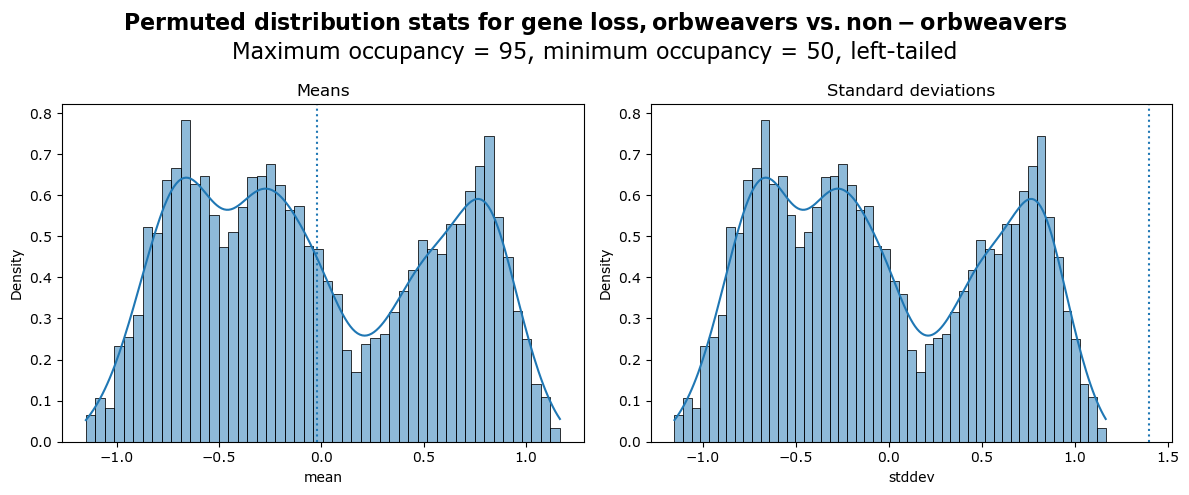

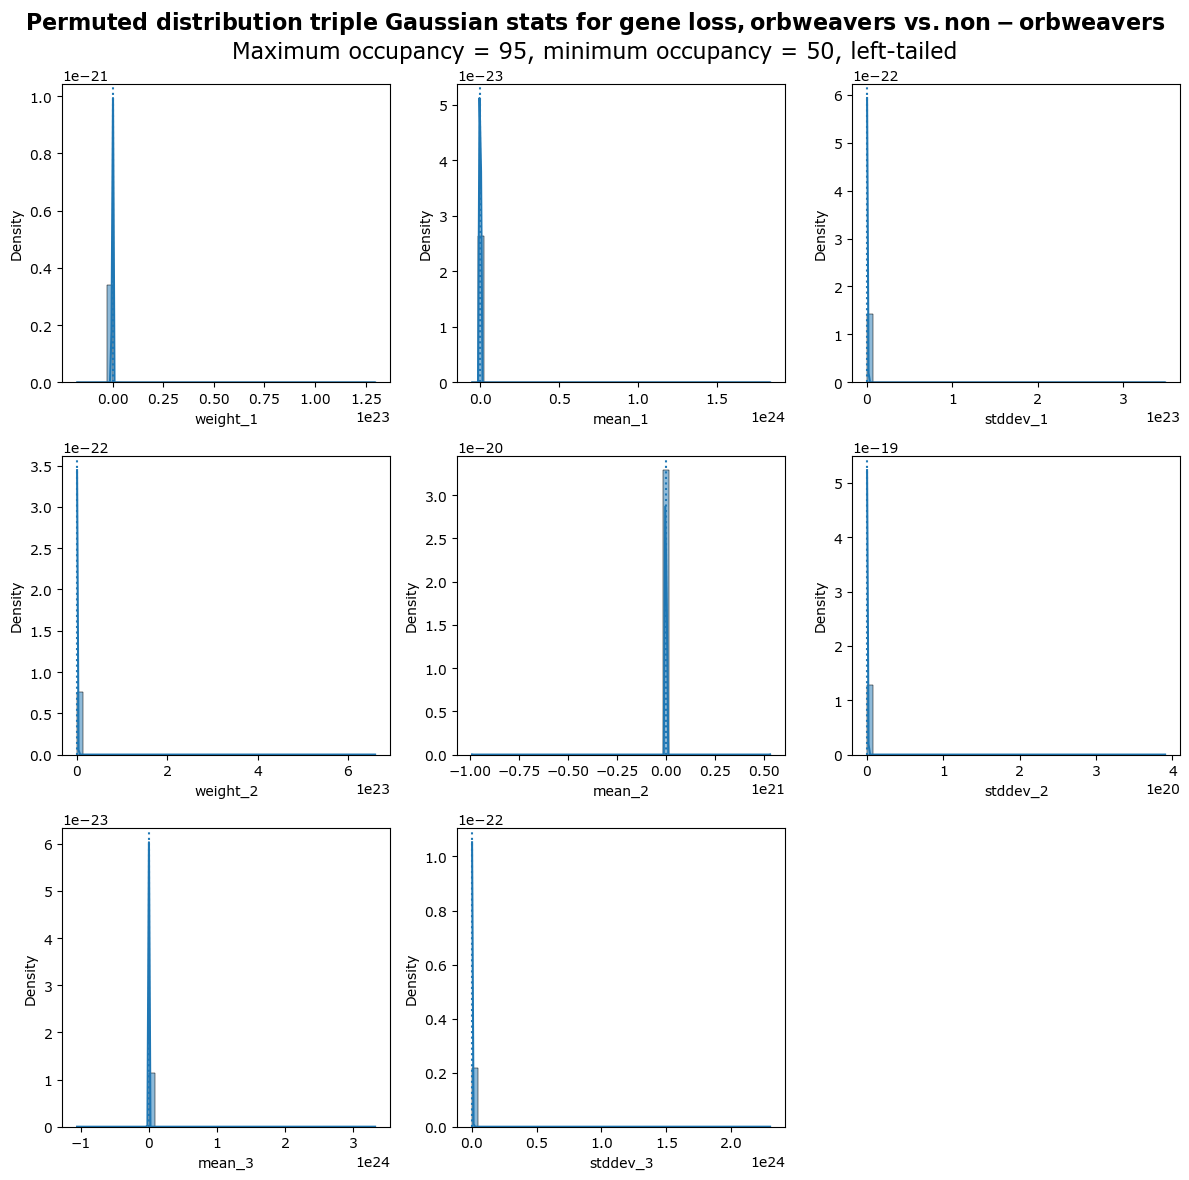

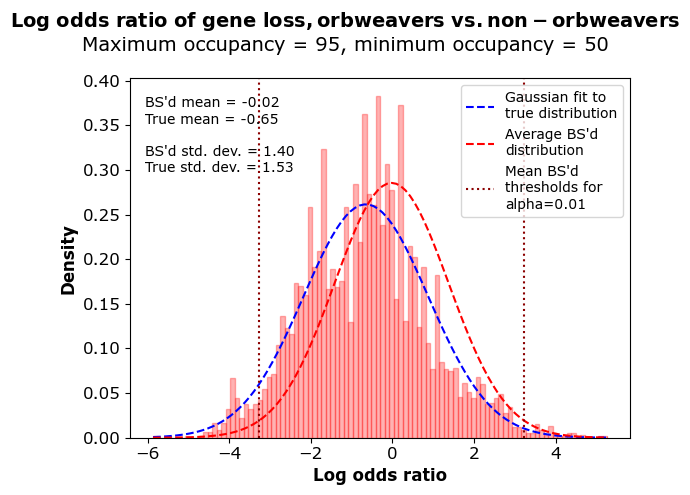

In [74]:
%autoreload 2
loss_lt_50_95 = ort.odds_ratio_test(
    test="loss",
    occupancy_threshold=50,
    max_occ=95,
    alpha=0.01,
    alternative="LT",
    permutation_reps = 10000,
    species_of_interest="Uloborus_diversus",
    results_dir=f"~/kelvin-scratch/random_bootstrap_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
)

98 species total, 44 foreground, 54 background
First permulated tip values (species -> value):
{'Tekellina_sadamotoi': 0.0, 'Robertus_nojimai': 0.0, 'Latrodectus_hasseltii': 0.0, 'Steatoda_grossa': 0.0, 'Rhomphaea_labiata': 0.0, 'Argyrodes_flavescens': 0.0, 'Argyrodes_miniaceus': 0.0, 'Cryptachaea_gigantipes': 0.0, 'Parasteatoda_culicivora': 0.0, 'Chrysso_octomaculata': 0.0, 'Theridion_varians': 0.0, 'Metleucauge_yunohamensis': 0.0, 'Mesida_sp_IDV5268': 0.0, 'Leucauge_dromedari': 0.0, 'Tetragnatha_yesoensis': 1.0, 'Tetragnatha_vermiformis': 1.0, 'Tetragnatha_mandibulata': 1.0, 'Tetragnatha_maxillosa': 1.0, 'Tetragnatha_extensa': 0.0, 'Tetragnatha_filiciphilia': 1.0, 'Tetragnatha_paludicola': 1.0, 'Tetragnatha_stelarobusta': 1.0, 'Tetragnatha_quasimodo': 1.0, 'Tetragnatha_waikamoi': 1.0, 'Tetragnatha_brevignatha': 1.0, 'Phonognatha_graeffei': 0.0, 'Caerostris_darwini': 1.0, 'Caerostris_extrusa': 1.0, 'Araneus_inustus': 1.0, 'Cyrtophora_cicatrosa': 1.0, 'Argiope_bruennichi': 1.0, 'Argiop

100%|██████████████████████████████████| 10000/10000 [1:38:04<00:00,  1.70it/s]



Permutation counter for MEAN (single Gaussian): 3254

Permutation counter for MEAN 1 (triple Gaussian): 479

Permutation counter for MEAN 2 (triple Gaussian): 7064

Permutation counter for MEAN 3 (triple Gaussian): 6982

Filtering log odds ratio results df for occupancy >= 50, <= 98
and log odds ratio threshold [-2.15794692  2.15126142]

Filtering for presence of Uloborus_diversus

*********************** RESULTS ***********************

Permutation test with 10000 repetitions for duplication (right-tailed)
with minimum occupancy *50* and maximum occupancy *no* 
Analysis run on 2026-03-22 at 22:46:26
Foreground list: /Users/calvin/orb-selection/assets/orbweavers-list.txt
Gene count file: /Users/calvin/orb-selection/assets/N5.GeneCount.tsv
Hierarchical orthogroup file: /Users/calvin/orb-selection/assets/N5.tsv

Total number of HOGs in node: 107986
Total number of HOGs within occupancy threshold: 7875
Total species: 98
Foreground count: 44
Background count: 54
True mean: 0.0316064244686

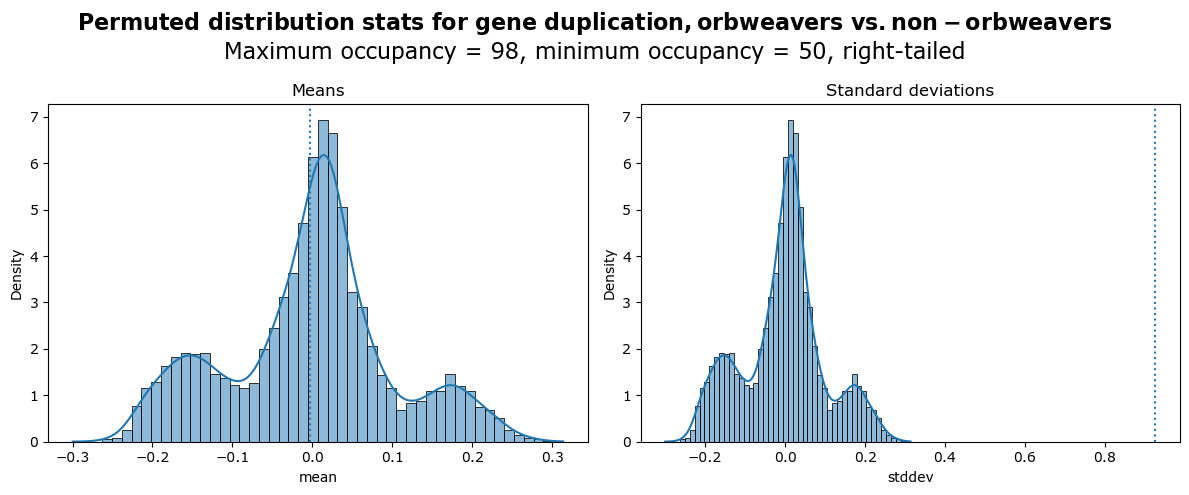

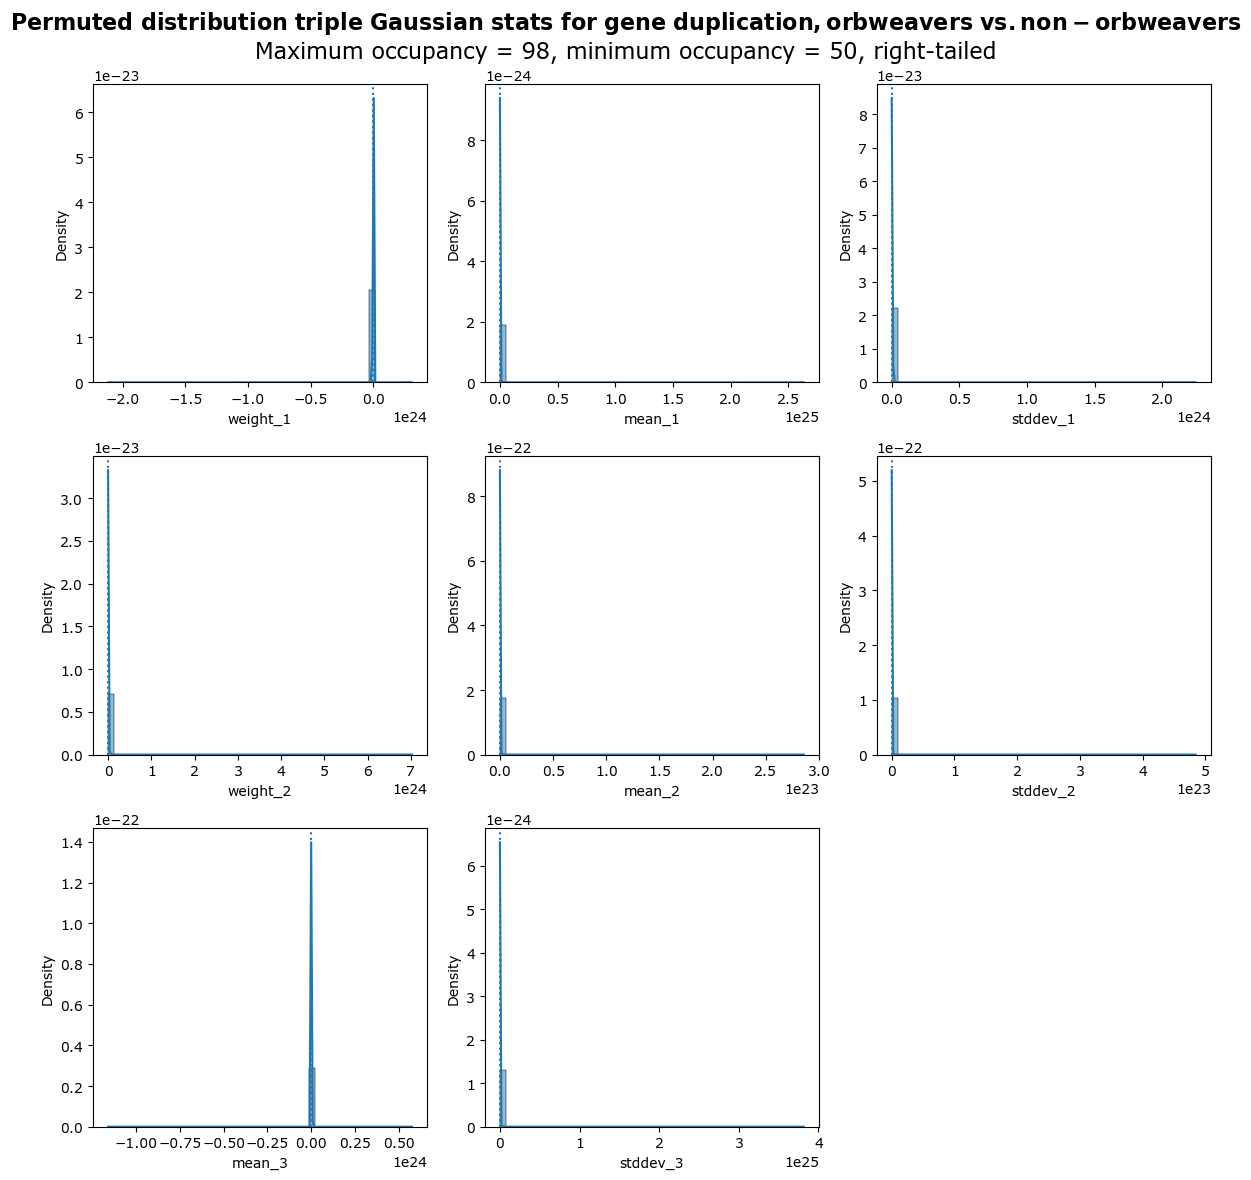

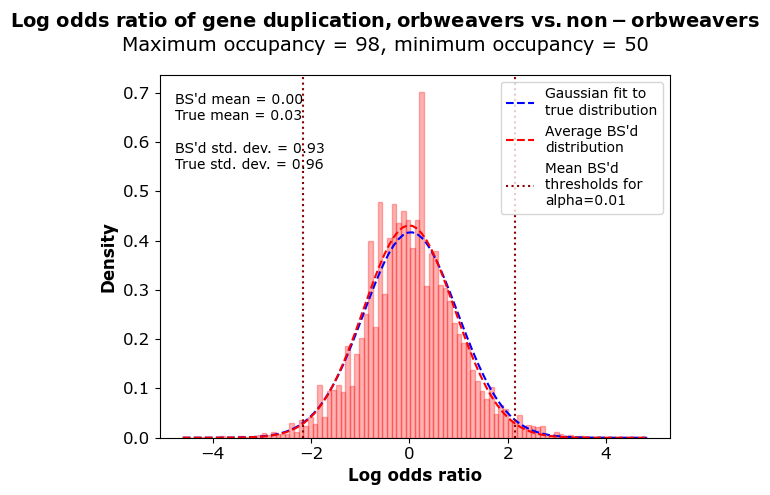

In [76]:
%autoreload 2
dup_rt_50_98 = ort.odds_ratio_test(
    test="duplication",
    occupancy_threshold=50,
    alpha=0.01,
    alternative="RT",
    permutation_reps = 10000,
    species_of_interest="Uloborus_diversus",
    results_dir=f"~/kelvin-scratch/random_bootstrap_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    )

In [82]:
(dup_rt_50_98.perm_tgauss_params[:, 3] < 0).sum()

np.int64(85)

In [ ]:
dup_rt_49_98_100k = ort.odds_ratio_test(
    test="duplication",
    occupancy_threshold=49,
    alternative="RT",
    species_of_interest="Uloborus_diversus",
    results_dir=f"results/odds_ratio_test",
    fg_name='orbweavers',
    bg_name='non-orbweavers',
    permutation_reps=100000,
    permulations_tip_values_csv="assets/perms_tip_values_100000.csv"
)

98 species total, 44 foreground, 54 background
First permulated tip values (species -> value):
{'Tekellina_sadamotoi': 1.0, 'Robertus_nojimai': 1.0, 'Latrodectus_hasseltii': 1.0, 'Steatoda_grossa': 1.0, 'Rhomphaea_labiata': 1.0, 'Argyrodes_flavescens': 1.0, 'Argyrodes_miniaceus': 1.0, 'Cryptachaea_gigantipes': 1.0, 'Parasteatoda_culicivora': 1.0, 'Chrysso_octomaculata': 1.0, 'Theridion_varians': 1.0, 'Metleucauge_yunohamensis': 1.0, 'Mesida_sp_IDV5268': 1.0, 'Leucauge_dromedari': 1.0, 'Tetragnatha_yesoensis': 0.0, 'Tetragnatha_vermiformis': 0.0, 'Tetragnatha_mandibulata': 0.0, 'Tetragnatha_maxillosa': 0.0, 'Tetragnatha_extensa': 0.0, 'Tetragnatha_filiciphilia': 0.0, 'Tetragnatha_paludicola': 0.0, 'Tetragnatha_stelarobusta': 0.0, 'Tetragnatha_quasimodo': 0.0, 'Tetragnatha_waikamoi': 0.0, 'Tetragnatha_brevignatha': 0.0, 'Phonognatha_graeffei': 0.0, 'Caerostris_darwini': 0.0, 'Caerostris_extrusa': 0.0, 'Araneus_inustus': 0.0, 'Cyrtophora_cicatrosa': 0.0, 'Argiope_bruennichi': 0.0, 'Argiop

  0%|                                   | 57/100000 [00:48<22:39:44,  1.23it/s]